Report on Biological Computation
Course code: BT5511
Course name: Advanced Biotechnology with Computation
Student ID: 52533165

In [3]:
# For file handling and searching
import os
import glob

#Aggregate Data from All Files

# Path to your data folder
data_folder = r'C:\Users\t08ag25\Desktop\Biocomputation'  

In [4]:
# To check if  code correctly found and accessed the files
file_list = glob.glob(os.path.join(data_folder, '*.tsv')) + glob.glob(os.path.join(data_folder, '*.txt'))

print(f"Found {len(file_list)} files:")
for f in file_list:
    print(f)


Found 24 files:
C:\Users\t08ag25\Desktop\Biocomputation\Ah3_data_file_17.txt
C:\Users\t08ag25\Desktop\Biocomputation\Alli8_data_file_16.txt
C:\Users\t08ag25\Desktop\Biocomputation\Anap7c1_data_file_3.txt
C:\Users\t08ag25\Desktop\Biocomputation\App1l8_data_file_7.txt
C:\Users\t08ag25\Desktop\Biocomputation\Avon4_data_file_2.txt
C:\Users\t08ag25\Desktop\Biocomputation\Cairn3a2_data_file_6.txt
C:\Users\t08ag25\Desktop\Biocomputation\Cairn6_data_file_12.txt
C:\Users\t08ag25\Desktop\Biocomputation\Clach6_data_file_22.txt
C:\Users\t08ag25\Desktop\Biocomputation\Dsgt9a1_data_file_5.txt
C:\Users\t08ag25\Desktop\Biocomputation\Ever6b6_data_file_23.txt
C:\Users\t08ag25\Desktop\Biocomputation\Everr1_data_file_8.txt
C:\Users\t08ag25\Desktop\Biocomputation\Got9_data_file_14.txt
C:\Users\t08ag25\Desktop\Biocomputation\Ist3_data_file_13.txt
C:\Users\t08ag25\Desktop\Biocomputation\Ist9a2_data_file_11.txt
C:\Users\t08ag25\Desktop\Biocomputation\Ist9a7_data_file_24.txt
C:\Users\t08ag25\Desktop\Biocomput

In [7]:
# List to store each gene's data
import pandas as pd
data_records = []

for file in file_list:
    df = pd.read_csv(file, sep='\t')
    data_records.append(df.iloc[0])  # Each file has one row of data

# To check if its correct
print(f"Number of records collected: {len(data_records)}")
print("First record preview:")
print(data_records[0])

Number of records collected: 24
First record preview:
Gene                                                                         Ah3
WildType.Sequence              TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...
Mutant.Sequence                TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...
mRNA.Expression.WT.Rep1                                         318313458.341669
mRNA.Expression.WT.Rep2                                                26.177081
mRNA.Expression.WT.Rep3                                                16.735333
mRNA.Expression.Mut.Rep1                                        318313458.972072
mRNA.Expression.Mut.Rep2                                               27.769621
mRNA.Expression.Mut.Rep3                                               17.761754
Protein.Expression.WT.Rep1                                                 11685
Protein.Expression.WT.Rep2                                                 26722
Protein.Expression.WT.Rep3                             

In [8]:
# Combine all records into a single DataFrame
all_data = pd.DataFrame(data_records)

In [9]:
# To check if it is combined
all_data = pd.DataFrame(data_records)

print(f"Shape of all_data: {all_data.shape}")  # (rows, columns)
print("First 3 rows of all_data:")
print(all_data.head(3))

Shape of all_data: (24, 21)
First 3 rows of all_data:
      Gene                                  WildType.Sequence  \
0      Ah3  TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...   
0    Alli8  TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...   
0  Anap7c1  GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...   

                                     Mutant.Sequence  mRNA.Expression.WT.Rep1  \
0  TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...             3.183135e+08   
0  TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...             6.389135e+01   
0  GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...             1.629126e+00   

   mRNA.Expression.WT.Rep2  mRNA.Expression.WT.Rep3  mRNA.Expression.Mut.Rep1  \
0                26.177081                16.735333              3.183135e+08   
0                 5.165643                13.914518              6.275914e+01   
0                20.977798                 7.266207             -3.674294e+00   

   mRNA.Expression.Mut.Rep2  mRNA.E

In [21]:
# Calculate Summary Statistics
import numpy as np

def safe_mean(values):
    try:
        arr = np.array(values, dtype=float)
        return arr.mean()
    except Exception as e:
        print(f"Error calculating mean: {e}")
        return np.nan


In [22]:
# Calculate means for each measurement

for prefix in ['mRNA.Expression', 'Protein.Expression', 'CellViability']:
    for state in ['WT', 'Mut']:
        cols = [f'{prefix}.{state}.Rep{i}' for i in range(1, 4)]
        all_data[f'{prefix}.{state}.Mean'] = all_data[cols].astype(float).mean(axis=1)
        all_data[f'{prefix}.{state}.Std'] = all_data[cols].astype(float).std(axis=1)

In [23]:
# Check results

print("Means and STDs for first 3 rows:")
print(all_data[[f'{prefix}.{state}.Mean' for prefix in ['mRNA.Expression', 'Protein.Expression', 'CellViability'] for state in ['WT', 'Mut']]].head(3))
print(all_data[[f'{prefix}.{state}.Std' for prefix in ['mRNA.Expression', 'Protein.Expression', 'CellViability'] for state in ['WT', 'Mut']]].head(3))

Means and STDs for first 3 rows:
   mRNA.Expression.WT.Mean  mRNA.Expression.Mut.Mean  \
0             1.061045e+08              1.061045e+08   
0             2.765717e+01              2.692833e+01   
0             9.957710e+00             -3.957048e+01   

   Protein.Expression.WT.Mean  Protein.Expression.Mut.Mean  \
0                25176.666667                 25184.000000   
0                20556.333333                 20565.333333   
0                21147.666667                 10071.333333   

   CellViability.WT.Mean  CellViability.Mut.Mean  
0               0.540463                0.599650  
0               0.136534                0.153044  
0               0.522474                0.000000  
   mRNA.Expression.WT.Std  mRNA.Expression.Mut.Std  Protein.Expression.WT.Std  \
0            1.837783e+08             1.837783e+08               12789.214297   
0            3.168316e+01             3.128717e+01               19531.316426   
0            9.951177e+00             6.051635

In [24]:
# Classify Mutation Type
def classify_mutation(wt_seq, mut_seq):
    if len(wt_seq) == len(mut_seq):
        # Substitution if only a few bases differ
        diff = sum(1 for a, b in zip(wt_seq, mut_seq) if a != b)
        if diff == 0:
            return 'None'
        elif diff < 10:
            return 'Substitution'
        else:
            return 'Complex'
    elif len(wt_seq) > len(mut_seq):
        return 'Deletion'
    elif len(wt_seq) < len(mut_seq):
        return 'Insertion'
    else:
        return 'Complex'

all_data['Mutation.Class'] = all_data.apply(
    lambda row: classify_mutation(row['WildType.Sequence'], row['Mutant.Sequence']), axis=1
)


In [25]:
# for results

print("Mutation.Class value counts:")
print(all_data['Mutation.Class'].value_counts())
print("\nFirst 5 Mutation.Class assignments:")
print(all_data[['WildType.Sequence', 'Mutant.Sequence', 'Mutation.Class']].head())

Mutation.Class value counts:
Mutation.Class
Substitution    11
Deletion         7
Insertion        6
Name: count, dtype: int64

First 5 Mutation.Class assignments:
                                   WildType.Sequence  \
0  TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...   
0  TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...   
0  GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...   
0  ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...   
0  TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...   

                                     Mutant.Sequence Mutation.Class  
0  TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...   Substitution  
0  TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...   Substitution  
0  GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...   Substitution  
0  ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...      Insertion  
0  TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...      Insertion  


In [26]:
#  Calculate Expression and Viability Changes
all_data['Delta_mRNA'] = all_data['mRNA.Expression.Mut.Mean'] - all_data['mRNA.Expression.WT.Mean']
all_data['Delta_Protein'] = all_data['Protein.Expression.Mut.Mean'] - all_data['Protein.Expression.WT.Mean']
all_data['Delta_Viability'] = all_data['CellViability.Mut.Mean'] - all_data['CellViability.WT.Mean']

In [27]:
# for results

print("Delta columns for first 5 rows:")
print(all_data[['Delta_mRNA', 'Delta_Protein', 'Delta_Viability']].head())


Delta columns for first 5 rows:
   Delta_mRNA  Delta_Protein  Delta_Viability
0    1.083121       7.333333         0.059187
0   -0.728842       9.000000         0.016510
0  -49.528187  -11076.333333        -0.522474
0   -0.425596       8.666667        -0.095330
0    1.445566   20031.666667         5.215711


In [28]:
# Identify Top 5 Genes for Validation
# prioritize genes with increased viability and expression

priority = all_data.sort_values(
    ['Delta_Viability', 'Delta_Protein', 'Delta_mRNA'], ascending=False
)
top5 = priority.head(5)
print(top5[['Gene', 'Mutation.Class', 'Delta_Viability', 'Delta_Protein', 'Delta_mRNA']])

      Gene Mutation.Class  Delta_Viability  Delta_Protein   Delta_mRNA
0    Avon4      Insertion         5.215711   20031.666667     1.445566
0   Ist9a2       Deletion         4.514477     -23.961772 -5010.362690
0  Nect1c1       Deletion         4.436899  -16614.000000    -0.743867
0  Ever6b6       Deletion         0.132621       9.333333    -0.813637
0   Everr1      Insertion         0.108869       6.666667     0.081817


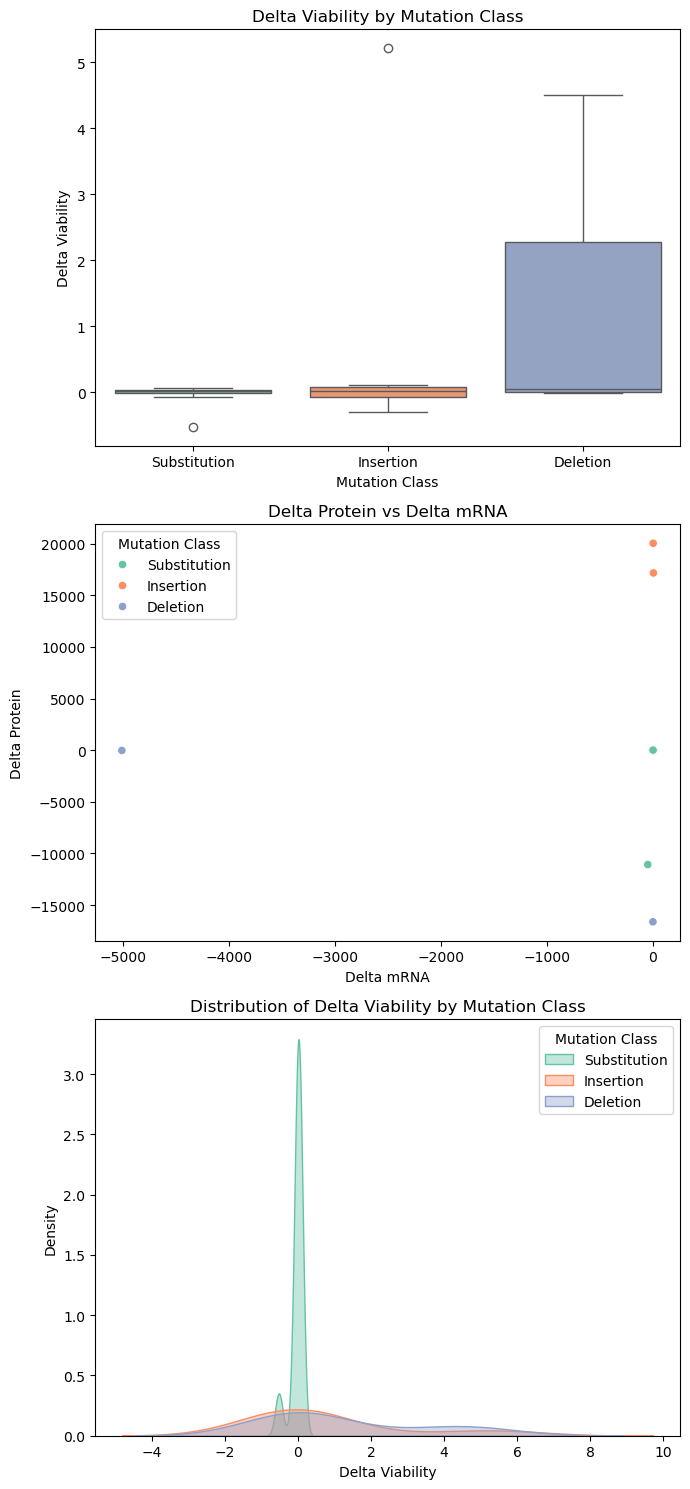

In [34]:
# Plotting graphs
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 15))  # Taller figure for vertical stacking

# Boxplot: Delta Viability by Mutation Class
plt.subplot(3, 1, 1)
sns.boxplot(
    x='Mutation.Class',
    y='Delta_Viability',
    hue='Mutation.Class',
    data=all_data,
    palette='Set2',
    legend=False
)
plt.title('Delta Viability by Mutation Class')
plt.xlabel('Mutation Class')
plt.ylabel('Delta Viability')

# Scatter: Delta Protein vs Delta mRNA
plt.subplot(3, 1, 2)
sns.scatterplot(
    x='Delta_mRNA',
    y='Delta_Protein',
    hue='Mutation.Class',
    data=all_data,
    palette='Set2',
    legend='full'
)
plt.title('Delta Protein vs Delta mRNA')
plt.xlabel('Delta mRNA')
plt.ylabel('Delta Protein')
plt.legend(title='Mutation Class')

# Histogram: Delta Viability by Mutation Class (with KDE lines)
plt.subplot(3, 1, 3)
for mutation_class, color in zip(all_data['Mutation.Class'].unique(), sns.color_palette('Set2')):
    subset = all_data[all_data['Mutation.Class'] == mutation_class]
    sns.kdeplot(
        subset['Delta_Viability'],
        label=mutation_class,
        color=color,
        fill=True,
        alpha=0.4
    )
plt.title('Distribution of Delta Viability by Mutation Class')
plt.xlabel('Delta Viability')
plt.ylabel('Density')
plt.legend(title='Mutation Class')

plt.tight_layout()
plt.show()

In [31]:
# to save 

top5.to_csv('top5_genes.csv', index=False)
plt.savefig('mutation_analysis_summary.png')